# Medical Sound Classification — LSTM + Bidirectioneel LSTM

Dit notebook bouwt voort op de bestaande YAMNet pipeline en vervangt de gemiddelde embedding (`np.mean`) door een volledige tijdreeks die door een LSTM wordt verwerkt.

**Wat nieuw is t.o.v. het origineel:**
- `extract_embeddings_sequence()`: geeft de volledige tijdreeks terug (niet gemiddeld)
- Padding/truncatie naar een vaste `max_frames` lengte
- Drie modelvarianten: LSTM, Bidirectioneel LSTM, en 1D CNN (als baseline)
- Metadata combinatie via Functional API
- Vergelijking van de drie modellen

## 0. Imports

In [18]:
import os
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import scipy.signal
import matplotlib.pyplot as plt

import tensorflow as tf
import tensorflow_hub as hub
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, Model

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

print("TensorFlow versie:", tf.__version__)
print("GPU beschikbaar:", tf.config.list_physical_devices('GPU'))

TensorFlow versie: 2.20.0
GPU beschikbaar: []


## 1. Data laden

In [19]:
df_train = pd.read_csv('data/train.csv')
df_test  = pd.read_csv('data/test.csv')

# Verwijder lege file
df_train = df_train.drop(df_train[df_train['candidateID'] == '5ee582f2832c2'].index)

# Missingness flag voor coldPresent
df_train['coldPresent_missing'] = df_train['coldPresent'].isna().astype(int)
df_train['coldPresent'] = df_train['coldPresent'].fillna(0)

print(f"Train samples: {len(df_train)}")
print(df_train['disease'].value_counts())

Train samples: 545
disease
1    238
2    167
0    140
Name: count, dtype: int64


In [20]:
import os
import shutil

def reorganize_by_disease(df, split='train'):
    if 'disease' not in df.columns:
        print(f"Skipping {split} set: no 'disease' column found")
        return

    for _, row in df.iterrows():
        cid = str(row['candidateID'])
        disease = str(int(row['disease'])) 
        
        # New target structure: spectrograms_final/train/0/candidate_id/
        target_dir = f'spectrograms_final/{split}/{disease}/{cid}'
        os.makedirs(target_dir, exist_ok=True)
        
        # Check for both cough and vowel
        for file_name in ['cough.png', 'vowel.png']:
            source_path = f'spectrograms/{split}/{cid}/{file_name}'
            
            if os.path.exists(source_path):
                # Copying file to the new ID-specific subfolder
                shutil.copy(source_path, os.path.join(target_dir, file_name))

# Reorganize the cleaned training set
reorganize_by_disease(df_train, split='train')
print("✅ Spectrograms reorganized by Disease -> Candidate ID")

✅ Spectrograms reorganized by Disease -> Candidate ID


## 2. YAMNet laden

In [21]:
yamnet_model = hub.load('https://tfhub.dev/google/yamnet/1')
print("YAMNet geladen.")

YAMNet geladen.


## 3. Embedding extractie — tijdreeks (nieuw!)

Het verschil met het origineel: in plaats van `np.mean(embeddings, axis=0)` bewaren we alle tijdsframes.
YAMNet verwerkt audio in vensters van ~0.96s met een hop van ~0.48s.
Bij een segment van 2 seconden krijg je dus ±4 frames, bij een langere opname meer.

In [23]:
def extract_embeddings_sequence(waveform, max_frames=50):
    """
    Geeft de volledige tijdreeks van YAMNet embeddings terug,
    gepadded of getruncate naar max_frames.
    
    Output shape: (max_frames, 1024)
    """
    if waveform.dtype != np.float32:
        waveform = waveform.astype(np.float32)
    
    scores, embeddings, spectrogram = yamnet_model(waveform)
    emb = embeddings.numpy()  # shape: (n_frames, 1024)
    
    n_frames = emb.shape[0]
    
    # Truncate als te lang
    if n_frames > max_frames:
        emb = emb[:max_frames]
    # Pad met nullen als te kort
    elif n_frames < max_frames:
        pad = np.zeros((max_frames - n_frames, 1024), dtype=np.float32)
        emb = np.vstack([emb, pad])
    
    return emb  # shape: (max_frames, 1024)


def extract_embeddings_mean(waveform):
    """Originele aanpak: gemiddeld over tijdsframes."""
    if waveform.dtype != np.float32:
        waveform = waveform.astype(np.float32)
    scores, embeddings, spectrogram = yamnet_model(waveform)
    return np.mean(embeddings.numpy(), axis=0)  # shape: (1024,)

### 3.1 Bepaal een goede max_frames waarde

We samplen een paar bestanden om te zien hoeveel frames we typisch hebben.

Frames — min: 4, max: 4, gemiddeld: 4.0, mediaan: 4


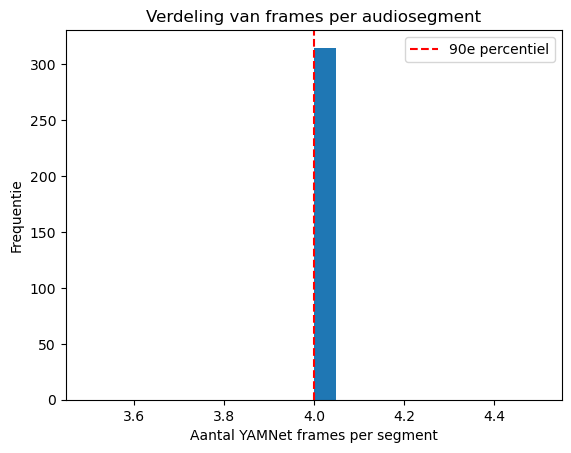


Aanbevolen MAX_FRAMES: 4


In [24]:
frame_counts = []

for cid in df_train['candidateID'].head(20):
    seg_folder = os.path.join("data/sounds/sounds", cid, "cough_segmented")
    if not os.path.exists(seg_folder):
        continue
    for fname in os.listdir(seg_folder):
        if fname.endswith("_processed.wav"):
            fp = os.path.join(seg_folder, fname)
            waveform, sr = librosa.load(fp, sr=16000)
            waveform = waveform.astype(np.float32)
            _, emb, _ = yamnet_model(waveform)
            frame_counts.append(emb.shape[0])

if frame_counts:
    print(f"Frames — min: {min(frame_counts)}, max: {max(frame_counts)}, "
          f"gemiddeld: {np.mean(frame_counts):.1f}, mediaan: {np.median(frame_counts):.0f}")
    plt.hist(frame_counts, bins=20)
    plt.xlabel('Aantal YAMNet frames per segment')
    plt.ylabel('Frequentie')
    plt.title('Verdeling van frames per audiosegment')
    plt.axvline(np.percentile(frame_counts, 90), color='r', linestyle='--', label='90e percentiel')
    plt.legend()
    plt.show()
    
    # Stel max_frames in op het 90e percentiel (dekt 90% van de data zonder te veel padding)
    MAX_FRAMES = int(np.percentile(frame_counts, 90))
    print(f"\nAanbevolen MAX_FRAMES: {MAX_FRAMES}")
else:
    MAX_FRAMES = 30
    print(f"Geen segmented bestanden gevonden. MAX_FRAMES ingesteld op {MAX_FRAMES}")

In [25]:
# Pas hier aan als je een andere waarde wil testen
MAX_FRAMES = MAX_FRAMES  # bijv. 20, 30, 50 ...
print(f"MAX_FRAMES = {MAX_FRAMES}")

MAX_FRAMES = 4


## 4. Dataset bouwen

We bouwen twee datasets:
- `X_seq`: tijdreeks embeddings, shape `(samples, MAX_FRAMES, 1024)` → voor LSTM
- `X_meta`: metadata features, shape `(samples, n_meta)` → apart gecombineerd

Cough segmenten + vowel (indien beschikbaar), net als in het origineel.

In [26]:
META_COLS = ['age', 'gender', 'tbContactHistory', 'wheezingHistory',
             'phlegmCough', 'familyAsthmaHistory', 'feverHistory',
             'coldPresent', 'packYears', 'coldPresent_missing']

df_filled = df_train.fillna(0)

X_seq  = []  # tijdreeks embeddings
X_meta = []  # metadata
y_list = []  # labels

skipped = 0

for _, row in df_filled.iterrows():
    cid     = row['candidateID']
    disease = row['disease']
    meta    = row[META_COLS].values.astype(np.float32)
    
    # --- Cough segmenten ---
    seg_folder = os.path.join("data/sounds/sounds", cid, "cough_segmented")
    if os.path.exists(seg_folder):
        for fname in os.listdir(seg_folder):
            if fname.endswith("_processed.wav"):
                fp = os.path.join(seg_folder, fname)
                try:
                    waveform, sr = librosa.load(fp, sr=16000)
                    emb_seq = extract_embeddings_sequence(waveform, MAX_FRAMES)
                    X_seq.append(emb_seq)
                    X_meta.append(meta)
                    y_list.append(disease)
                except Exception as e:
                    print(f"Fout bij {fp}: {e}")
                    skipped += 1
    
    # --- Vowel ---
    vowel_path = os.path.join("data/sounds/sounds", cid, "vowel_processed.wav")
    if os.path.isfile(vowel_path):
        try:
            waveform, sr = librosa.load(vowel_path, sr=16000)
            emb_seq = extract_embeddings_sequence(waveform, MAX_FRAMES)
            X_seq.append(emb_seq)
            X_meta.append(meta)
            y_list.append(disease)
        except Exception as e:
            print(f"Fout bij {vowel_path}: {e}")
            skipped += 1

X_seq  = np.array(X_seq,  dtype=np.float32)   # (samples, MAX_FRAMES, 1024)
X_meta = np.array(X_meta, dtype=np.float32)   # (samples, n_meta)
y_arr  = np.array(y_list)

print(f"X_seq shape : {X_seq.shape}")
print(f"X_meta shape: {X_meta.shape}")
print(f"Labels shape: {y_arr.shape}")
print(f"Overgeslagen : {skipped}")

X_seq shape : (8858, 4, 1024)
X_meta shape: (8858, 10)
Labels shape: (8858,)
Overgeslagen : 0


In [9]:
# Metadata schalen
scaler = StandardScaler()
X_meta_scaled = scaler.fit_transform(X_meta)

# Labels encoderen
le = LabelEncoder()
y_encoded = le.fit_transform(y_arr)
num_classes = len(le.classes_)
print(f"Klassen: {le.classes_}  ({num_classes} klassen)")

# Train/val split — gestratificeerd
(
    X_seq_train, X_seq_val,
    X_meta_train, X_meta_val,
    y_train, y_val
) = train_test_split(
    X_seq, X_meta_scaled, y_encoded,
    test_size=0.2, random_state=42, stratify=y_encoded
)

y_train_oh = to_categorical(y_train, num_classes)
y_val_oh   = to_categorical(y_val,   num_classes)

print(f"Training  : {len(X_seq_train)} samples")
print(f"Validatie : {len(X_seq_val)} samples")

Klassen: [0 1 2]  (3 klassen)
Training  : 7086 samples
Validatie : 1772 samples


## 5. Modellen

We bouwen drie varianten en vergelijken ze:

| Model | Beschrijving |
|-------|--------------|
| **LSTM** | Unidirectionele LSTM over tijdreeks + metadata |
| **BiLSTM** | Bidirectionele LSTM (kijkt ook achteruit) + metadata |
| **1D CNN** | Convoluties over de tijdas (sneller, stabiel bij kleine data) + metadata |

In [10]:
def build_lstm(max_frames, n_meta, num_classes, bidirectional=False):
    """
    Functional API model: tijdreeks (LSTM) + metadata gecombineerd.
    """
    # --- Audio tak ---
    audio_input = layers.Input(shape=(max_frames, 1024), name='audio_seq')
    
    lstm_layer = layers.LSTM(128, return_sequences=True)(audio_input)
    lstm_layer = layers.Dropout(0.3)(lstm_layer)
    lstm_layer = layers.LSTM(64)(lstm_layer)
    lstm_layer = layers.Dropout(0.3)(lstm_layer)
    
    if bidirectional:
        audio_input = layers.Input(shape=(max_frames, 1024), name='audio_seq')
        lstm_layer = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(audio_input)
        lstm_layer = layers.Dropout(0.3)(lstm_layer)
        lstm_layer = layers.Bidirectional(layers.LSTM(64))(lstm_layer)
        lstm_layer = layers.Dropout(0.3)(lstm_layer)
    
    # --- Metadata tak ---
    meta_input = layers.Input(shape=(n_meta,), name='metadata')
    meta_dense = layers.Dense(32, activation='relu')(meta_input)
    meta_dense = layers.Dropout(0.2)(meta_dense)
    
    # --- Combineer ---
    combined = layers.concatenate([lstm_layer, meta_dense])
    out = layers.Dense(64, activation='relu')(combined)
    out = layers.Dropout(0.3)(out)
    out = layers.Dense(num_classes, activation='softmax')(out)
    
    model = Model(inputs=[audio_input, meta_input], outputs=out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


def build_1d_cnn(max_frames, n_meta, num_classes):
    """
    1D CNN over de tijdreeks van embeddings — vaak stabieler bij kleine datasets.
    """
    # --- Audio tak ---
    audio_input = layers.Input(shape=(max_frames, 1024), name='audio_seq')
    
    x = layers.Conv1D(128, kernel_size=3, activation='relu', padding='same')(audio_input)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Conv1D(64, kernel_size=3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.4)(x)
    
    # --- Metadata tak ---
    meta_input = layers.Input(shape=(n_meta,), name='metadata')
    meta_dense = layers.Dense(32, activation='relu')(meta_input)
    meta_dense = layers.Dropout(0.2)(meta_dense)
    
    # --- Combineer ---
    combined = layers.concatenate([x, meta_dense])
    out = layers.Dense(64, activation='relu')(combined)
    out = layers.Dropout(0.3)(out)
    out = layers.Dense(num_classes, activation='softmax')(out)
    
    model = Model(inputs=[audio_input, meta_input], outputs=out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


n_meta = X_meta_scaled.shape[1]
print(f"n_meta features: {n_meta}")

n_meta features: 10


## 6. Training

We trainen de drie modellen na elkaar en slaan de resultaten op voor vergelijking.

In [11]:
def train_model(model, name, epochs=60, batch_size=16):
    print(f"\n{'='*50}")
    print(f"Training: {name}")
    print(f"{'='*50}")
    model.summary()
    
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    )
    
    history = model.fit(
        [X_seq_train, X_meta_train], y_train_oh,
        validation_data=([X_seq_val, X_meta_val], y_val_oh),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=1
    )
    
    val_loss, val_acc = model.evaluate([X_seq_val, X_meta_val], y_val_oh, verbose=0)
    y_pred = np.argmax(model.predict([X_seq_val, X_meta_val], verbose=0), axis=1)
    macro_f1 = f1_score(y_val, y_pred, average='macro')
    
    print(f"\n{name} — Val Accuracy: {val_acc:.4f} | Macro F1: {macro_f1:.4f}")
    print(classification_report(y_val, y_pred, target_names=le.classes_.astype(str)))
    
    return history, val_acc, macro_f1, y_pred

In [12]:
# --- LSTM ---
lstm_model = build_lstm(MAX_FRAMES, n_meta, num_classes, bidirectional=False)
hist_lstm, acc_lstm, f1_lstm, pred_lstm = train_model(lstm_model, "LSTM")


Training: LSTM


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ audio_seq           │ (None, 4, 1024)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 4, 128)    │    590,336 │ audio_seq[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 4, 128)    │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ metadata            │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 64)        │     49,408 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │        352 │ metadata[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 96)        │          0 │ dropout_1[0][0],  │
│ (Concatenate)       │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      6,208 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 3)         │        195 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 646,499 (2.47 MB)

 Trainable params: 646,499 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.7162 - loss: 0.6661 - val_accuracy: 0.8234 - val_loss: 0.4530
Epoch 2/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8100 - loss: 0.4956 - val_accuracy: 0.8392 - val_loss: 0.4103
Epoch 3/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8243 - loss: 0.4602 - val_accuracy: 0.8459 - val_loss: 0.3861
Epoch 4/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8331 - loss: 0.4363 - val_accuracy: 0.8493 - val_loss: 0.3738
Epoch 5/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8393 - loss: 0.4152 - val_accuracy: 0.8589 - val_loss: 0.3490
Epoch 6/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8455 - loss: 0.4029 - val_accuracy: 0.8623 - val_loss: 0.3395
Epoch 7/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8515 - loss: 0.3804 - val_accuracy: 0.8702 - val_loss: 0.3378
Epoch 8/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8542 - loss: 0.3660 - val_accu

In [13]:
# --- Bidirectioneel LSTM ---
bilstm_model = build_lstm(MAX_FRAMES, n_meta, num_classes, bidirectional=True)
hist_bilstm, acc_bilstm, f1_bilstm, pred_bilstm = train_model(bilstm_model, "BiLSTM")


Training: BiLSTM


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ audio_seq           │ (None, 4, 1024)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 4, 256)    │  1,180,672 │ audio_seq[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 4, 256)    │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ metadata            │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 128)       │    164,352 │ dropout_6[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │        352 │ metadata[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 128)       │          0 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 32)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 160)       │          0 │ dropout_7[0][0],  │
│ (Concatenate)       │                   │            │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │     10,304 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 64)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 3)         │        195 │ dropout_9[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,355,875 (5.17 MB)

 Trainable params: 1,355,875 (5.17 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.7434 - loss: 0.6277 - val_accuracy: 0.8437 - val_loss: 0.4352
Epoch 2/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8263 - loss: 0.4718 - val_accuracy: 0.8572 - val_loss: 0.3921
Epoch 3/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8312 - loss: 0.4409 - val_accuracy: 0.8567 - val_loss: 0.3705
Epoch 4/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8397 - loss: 0.4085 - val_accuracy: 0.8510 - val_loss: 0.3600
Epoch 5/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8465 - loss: 0.3942 - val_accuracy: 0.8685 - val_loss: 0.3435
Epoch 6/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8534 - loss: 0.3805 - val_accuracy: 0.8651 - val_loss: 0.3243
Epoch 7/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8579 - loss: 0.3604 - val_accuracy: 0.8679 - val_loss: 0.3187
Epoch 8/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8696 - loss: 0.3439 - val_acc

In [14]:
# --- 1D CNN ---
cnn_model = build_1d_cnn(MAX_FRAMES, n_meta, num_classes)
hist_cnn, acc_cnn, f1_cnn, pred_cnn = train_model(cnn_model, "1D CNN")


Training: 1D CNN


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ audio_seq           │ (None, 4, 1024)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 4, 128)    │    393,344 │ audio_seq[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 4, 128)    │        512 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 2, 128)    │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 2, 64)     │     24,640 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2, 64)     │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ metadata            │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 32)        │        352 │ metadata[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 64)        │          0 │ global_average_p… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 32)        │          0 │ dense_6[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 96)        │          0 │ dropout_10[0][0], │
│ (Concatenate)       │                   │            │ dropout_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 64)        │      6,208 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 64)        │          0 │ dense_7[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 3)         │        195 │ dropout_12[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 425,507 (1.62 MB)

 Trainable params: 425,123 (1.62 MB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.7051 - loss: 0.6859 - val_accuracy: 0.8245 - val_loss: 0.4624
Epoch 2/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8100 - loss: 0.4971 - val_accuracy: 0.8301 - val_loss: 0.4173
Epoch 3/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8230 - loss: 0.4582 - val_accuracy: 0.8488 - val_loss: 0.3873
Epoch 4/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8407 - loss: 0.4249 - val_accuracy: 0.8476 - val_loss: 0.3681
Epoch 5/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8426 - loss: 0.4177 - val_accuracy: 0.8533 - val_loss: 0.3624
Epoch 6/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8386 - loss: 0.4071 - val_accuracy: 0.8493 - val_loss: 0.3529
Epoch 7/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8445 - loss: 0.4006 - val_accuracy: 0.8612 - val_loss: 0.3468
Epoch 8/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8449 - loss: 0.3894 - val_accu

## 7. Vergelijking

 Model  Val Accuracy  Macro F1
  LSTM      0.880361  0.877048
BiLSTM      0.874153  0.870365
1D CNN      0.884311  0.880616


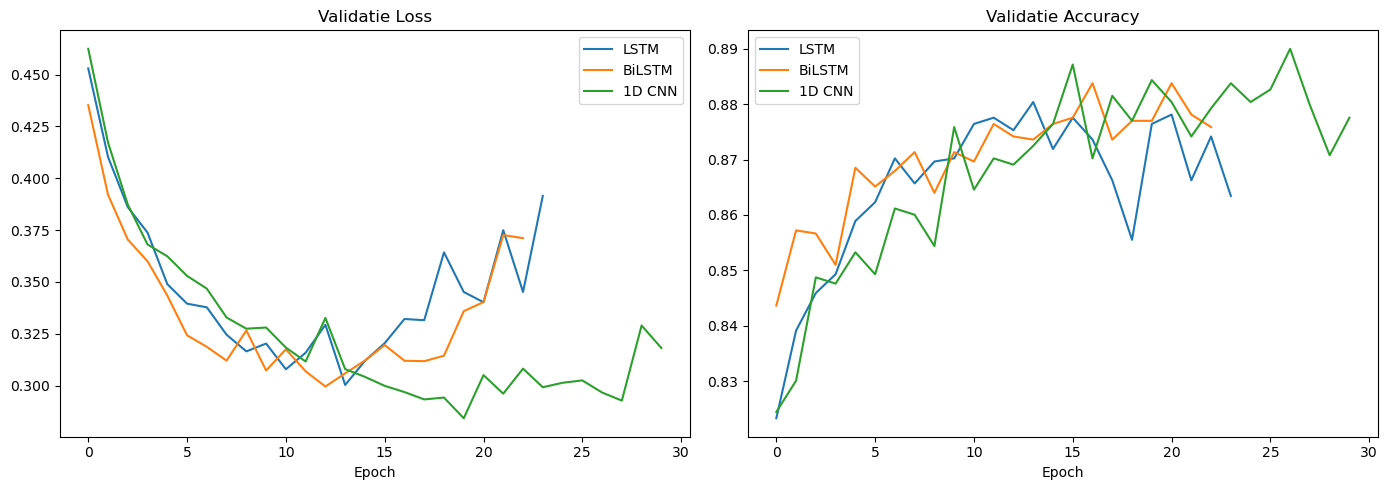

In [15]:
results = pd.DataFrame({
    'Model'      : ['LSTM', 'BiLSTM', '1D CNN'],
    'Val Accuracy': [acc_lstm, acc_bilstm, acc_cnn],
    'Macro F1'   : [f1_lstm,  f1_bilstm,  f1_cnn]
})
print(results.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for hist, name in [(hist_lstm, 'LSTM'), (hist_bilstm, 'BiLSTM'), (hist_cnn, '1D CNN')]:
    axes[0].plot(hist.history['val_loss'], label=name)
    axes[1].plot(hist.history['val_accuracy'], label=name)

axes[0].set_title('Validatie Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].set_title('Validatie Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

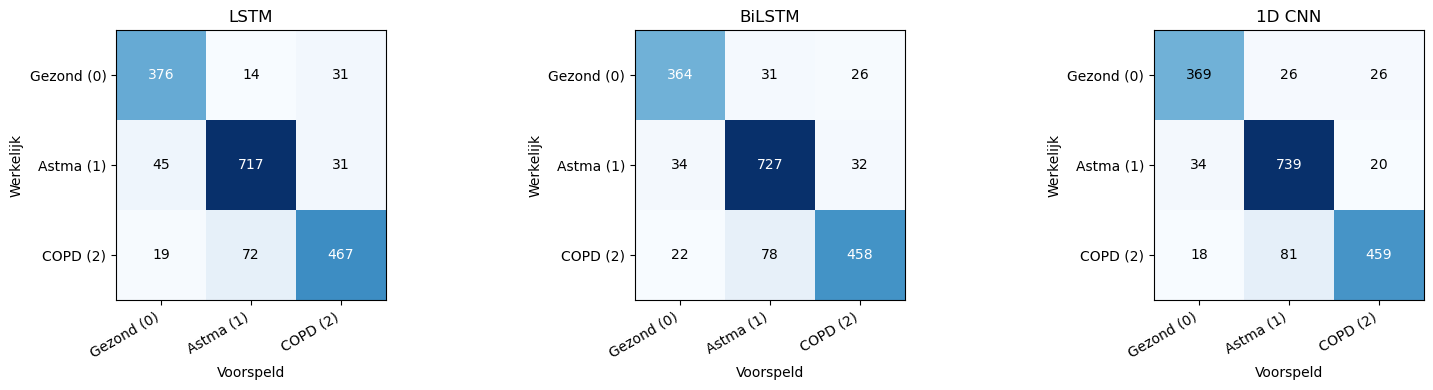

In [16]:
# Confusion matrices naast elkaar
class_names = ['Gezond (0)', 'Astma (1)', 'COPD (2)']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, preds, name in [
    (axes[0], pred_lstm,   'LSTM'),
    (axes[1], pred_bilstm, 'BiLSTM'),
    (axes[2], pred_cnn,    '1D CNN')
]:
    cm = confusion_matrix(y_val, preds)
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(name)
    ax.set_xticks(range(num_classes))
    ax.set_yticks(range(num_classes))
    ax.set_xticklabels(class_names, rotation=30, ha='right')
    ax.set_yticklabels(class_names)
    ax.set_xlabel('Voorspeld')
    ax.set_ylabel('Werkelijk')
    for i in range(num_classes):
        for j in range(num_classes):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.tight_layout()
plt.show()

## 8. Beste model opslaan

In [17]:
import joblib

best_f1 = max(f1_lstm, f1_bilstm, f1_cnn)
best_name = ['LSTM', 'BiLSTM', '1D CNN'][[f1_lstm, f1_bilstm, f1_cnn].index(best_f1)]
best_model = {'LSTM': lstm_model, 'BiLSTM': bilstm_model, '1D CNN': cnn_model}[best_name]

print(f"Beste model: {best_name} (Macro F1 = {best_f1:.4f})")

best_model.save(f"best_model_{best_name.replace(' ', '_').lower()}.keras")
joblib.dump(scaler, "scaler_lstm_experiment.pkl")
joblib.dump(le,     "label_encoder_lstm_experiment.pkl")

print("Model, scaler en label encoder opgeslagen.")

Beste model: 1D CNN (Macro F1 = 0.8806)
Model, scaler en label encoder opgeslagen.


## 9. Inferentie op testset (optioneel)

Pas dit aan naar de structuur van jouw test CSV.

In [22]:
# Uncomment en pas aan zodra je de testset wil evalueren

# df_test_filled = df_test.fillna(0)
# if 'coldPresent_missing' not in df_test_filled.columns:
#     df_test_filled['coldPresent_missing'] = df_test['coldPresent'].isna().astype(int)

# X_seq_test  = []
# X_meta_test = []
# test_ids    = []

# for _, row in df_test_filled.iterrows():
#     cid  = row['candidateID']
#     meta = row[META_COLS].values.astype(np.float32)
#
#     seg_folder = os.path.join("data/sounds/sounds", cid, "cough_segmented")
#     if os.path.exists(seg_folder):
#         for fname in os.listdir(seg_folder):
#             if fname.endswith("_processed.wav"):
#                 fp = os.path.join(seg_folder, fname)
#                 waveform, _ = librosa.load(fp, sr=16000)
#                 emb_seq = extract_embeddings_sequence(waveform, MAX_FRAMES)
#                 X_seq_test.append(emb_seq)
#                 X_meta_test.append(meta)
#                 test_ids.append(cid)

# X_seq_test  = np.array(X_seq_test,  dtype=np.float32)
# X_meta_test = scaler.transform(np.array(X_meta_test, dtype=np.float32))

# y_pred_test = np.argmax(best_model.predict([X_seq_test, X_meta_test]), axis=1)
# y_pred_labels = le.inverse_transform(y_pred_test)

# submission = pd.DataFrame({'candidateID': test_ids, 'disease': y_pred_labels})
# # Aggregeer per kandidaat (meerdere segmenten → majority vote)
# submission = submission.groupby('candidateID')['disease'].agg(lambda x: x.mode()[0]).reset_index()
# submission.to_csv('submission_lstm.csv', index=False)
# print(submission.head())

print("Testset inferentie klaar om te gebruiken — uncomment de code hierboven.")

Testset inferentie klaar om te gebruiken — uncomment de code hierboven.
